In [3]:
# !pip install pyts
# !pip install dtaidistance

# Домашнее задание

1. Генерим 21 сигналов (временных рядов), 3 класса по 7 образцов в каждом. 
Постарайтесь сделать их как можно более похожими, и в тоже время различными. 

1. Рассчитываем расстояние между ними по формуле Евклида и с помощью DTW

1. Описываем кратко полученные значения

1. Формируем из нагенеренных временных рядов набор данных для обучения

1. Разбиваем набор на train и test

1. Обучаем  классификаторы KNN с DTW, KNN со стандартной метрикой расстояния, TimeSeriesForest

1. Описываем кратко полученные результаты

In [4]:
import matplotlib.pyplot as plt
import numpy as np

Генерация сигнала

1 тип - гармонический (косинус)

2 тип - модифицированный синус

3 тип - пульс - сигнал

Для выполнения дз надо нагенерить 21 сигнал, по 7 сигналов каждого типа

In [5]:
def pulse(t):
    """Пульс сигнал"""
    return 1 * (abs(t) < 0.5)

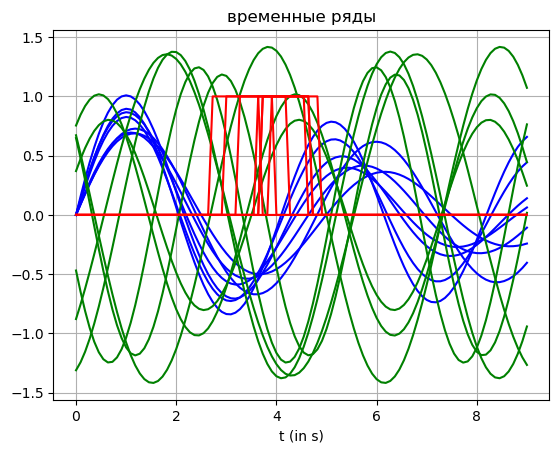

In [6]:
# индекс и отсчет времени в секундах
time_index = np.linspace(0, 9, 100)

tseries_list = {'Time': time_index}
d = np.random.random(size=10)


N = 7 #количество образцов в каждом типе сигналов

# гармонические колебания
f0 = 0.2

# гармонические колебания
for i in range(N):
    tseries_list["Tc"+str(i)] = (0.8 + 0.7*d[i]) * np.cos(2*np.pi*(f0 + 0.1*d[(i+1)%10])*time_index + 2*np.pi*d[(i+2)%10])

# модифицированный синус
for i in range(N):
    tseries_list["Ts"+str(i)] = (1.2 - 0.5*d[i]) * np.sin(2*np.pi*(f0 + 0.05*d[(i+1)%10])*time_index) * np.exp(-0.2*d[(i+2)%10]*time_index)

# пульс-сигнал 
for i in range(N):
    tseries_list["Tp"+str(i)] = pulse(time_index - 4 + np.random.uniform(-1, 1))

# отрисовка всех сигналов
for i in range(N):
    pass # Закомментировано или удалено, чтобы не падало до выполнения TODO
    plt.plot(time_index, tseries_list["Ts"+str(i)], '-b')
for i in range(N):
    plt.plot(time_index, tseries_list["Tc"+str(i)], '-g')
for i in range(N):
    plt.plot(time_index, tseries_list["Tp"+str(i)], '-r')
            
plt.title(r'временные ряды')
plt.xlabel(r't (in s)')
plt.grid()

# Понимание Динамическое искажение (деформация) времени (Dynamic time warping, DTW)

DTW - это метод, который вычисляет оптимальное соответствие между двумя заданными последовательностями (например, временными рядами) с определенными ограничениями и правилами:

1. Каждый индекс из первой последовательности должен быть сопоставлен с одним или несколькими индексами из другой последовательности и наоборот

1. Первый индекс из первой последовательности должен совпадать с первым индексом из другой последовательности (но это не обязательно должно быть его единственным совпадением)

1. Последний индекс из первой последовательности должен совпадать с последним индексом из другой последовательности (но это не обязательно должно быть его единственным совпадением)

1. Отображение индексов из первой последовательности на индексы из другой последовательности должно монотонно возрастать, и наоборот, т. е. если j>i являются индексами из первой последовательности, то в другой последовательности не должно быть двух индексов l> k, так что индекс i совпадает с индексом l, а индекс j - с индексом k, и наоборот.

Рассмотрим два временных ряда $x$ и $x^{\prime}$ соответствующей длины n и m. Предполагается, что все элементы этих рядов лежат в одном и том же  p - одномерном пространство и точные временные метки, в которые происходят наблюдения, не принимаются во внимание, важен только их порядок.

Более формально задача оптимизации записывается в виде:

$
DTW_q({x}, {x}^\prime) =
    \min_{\pi \in \mathcal{A}({x}, {x}^\prime)}
        \left( \sum_{(i, j) \in \pi} d(x_i, x^\prime_j)^q \right)^{\frac{1}{q}}
$

 
Здесь путь выравнивания $\pi$  длины K  представляет собой последовательность K  пары индексов $((i_0,j_0),..,(i_{K-1},j_{K-1}))$
 и  $A(x,x^{\prime})$
 представляет собой набор всех допустимых путей. Чтобы считаться допустимым, путь должен удовлетворять следующим условиям:

Начало (соответственно, конец) временных рядов сопоставляются друг с другом:

$
\pi_0 = (0, 0)
$

$
\pi_{K-1} = (n - 1, m - 1)
$

Последовательность монотонно увеличивается в обоих $i$ и $j$  и все индексы временных рядов должны отображаться хотя бы один раз, что может быть записано как:

$
i_{k-1} \leq i_k \leq i_{k-1} + 1
$

$
j_{k-1} \leq j_k \leq j_{k-1} + 1
$


Другим способом представления  DTW является использование двоичной матрицы, ненулевые элементы которой соответствуют совпадениям между элементами временного ряда. Это представление связано с представлением последовательности индексов, использованным выше:

$
\begin{equation}
(A_\pi)_{i,j} = \left\{ \begin{array}{rl} 1 & \text{ if } (i, j) \in \pi \\
                                      0 & \text{ otherwise}
                        \end{array} \right. \,\,\,\,\,\,\, .
\end{equation}
$

Тогда  DTW может быть выражено через скалярные произведения следующим образом:

$
DTW_q({x}, {x}^\prime) =
    \min_{\pi \in \mathcal{A}({x}, {x}^\prime)}
        \left\langle A_\pi,  D_q({x}, {x}^\prime) \right\rangle^{\frac{1}{q}}
 $ 

Решение поставленной задачи оптимизации может быть найдено с помощью динамического программирования.
Обозначим:

$
R_{i,j} = DTW_q({x}_{\rightarrow i}, {x}^\prime_{\rightarrow j})^q
$

где ${x}_{\rightarrow i}$ - обозначает наблюдение ряда до отметки i

Тогда получаем реккурентную формулу:

$
\begin{aligned}
R_{i,j} 
    &= \min_{\pi \in \mathcal{A}({x}_{\rightarrow i}, {x}^\prime_{\rightarrow j})}
        \sum_{(k, l) \in \pi} d(x_k, x^\prime_l)^q \\
    &\stackrel{*}{=} d(x_i, x^\prime_j)^q +
        \min_{\pi \in \mathcal{A}({x}_{\rightarrow i}, {x}^\prime_{\rightarrow j})}
            \sum_{(k, l) \in \pi[:-1]} d(x_k, x^\prime_l)^q \\
    &\stackrel{**}{=} d(x_i, x^\prime_j)^q +
        \min ({\color{Blue}R_{i-1, j}}, {\color{Red}R_{i, j-1}}, {\color{ForestGreen}R_{i-1, j-1}})
\end{aligned}
$

\* - потому, что последний элемент на допустимом пути должен соответствовать последним элементам ряда.

** - результат условий смежности допустимых путей.

In [7]:
def distance_matrix(x, y, q) -> np.array:
    """
    Функция  рассчета  матрицы  расстояний между точками двух рядов 
    """
    mdist = np.zeros((len(y), len(x)))
    # TODO: Напишите вложенные циклы для заполнения матрицы mdist расстояниями: |x[j] - y[i]|**q
    
    for i in range(len(y)):
        for j in range(len(x)):
            mdist[i, j] = np.abs(x[j] - y[i]) ** q

    return mdist

In [8]:
# Посчитаем DTW для двух временных рядов
# Сначала напишем функцию, которая это все вычисляет


def DTW(x, x_s, q=1, isDTW=True):
    '''
        x: первый ряд
        x_s : второй ряд
        q : степень для вычисления базового расстояния
    '''
    N = len(x) # Считаем, что ряды равной длины. Но это не всегда так, перепишите функцию для 
               # вычисления расстояния между рядами, длины которых не равны
    
    # Строим матрицу согласно реккурентной формуле, полученной выше. Матрица в нашем случае будет размерности 

    dist = distance_matrix(x,x_s,q=2)
    
    R = [[0] * (N+1) for i in range(N+1)]
   
    for i in range(1,N): 
        R[i][0] = dist[i,0] + R[i-1][0] 
        R[0][i] = dist[0,i] + R[0][i-1]
    
    # проверяем, что записалось
    print("Начинаем заполнять матрицу R")
    for i in range(N+1): 
        print(R[i])

    k = 0
    if isDTW:
        k = 1
    
    # начинаем расчет по реккурентной формуле
  
    for i in range(1,N+1): 
        for j in range(1,N+1):
            R[i][j] = dist[i-1][j-1] + min(
                R[i-1][j],
                R[i][j-1],
                R[i-1][j-1] * k ) 
    "TODO: Реализуйте шаг вычисления реккурентной формулы расчета матрицы R для DTW"

    # проверяем, что записалось
    print("\nпосле заполнения матрицы R")
    for i in range(N+1): 
        print(R[i])

    # ищем минимальный путь. Начинаем от нижнего правого угла.
    pth = []   # лист с кортежами индексов пути
    i = N
    j = N
    while i >= 0 and j >= 0:
        pth.append((i,j))
        if R[i][j-1] <= R[i-1][j-1] and R[i][j-1] <= R[i-1][j]:
            I = i
            J = j-1                
        
        if R[i-1][j] <= R[i-1][j-1] and R[i-1][j] <= R[i][j-1]:
            I = i - 1
            J = j 

        if R[i-1][j-1] <= R[i][j-1] and R[i-1][j-1] <= R[i-1][j]:
            I = i - 1
            J = j - 1
        
        i = I
        j = J
    
            
    print("\nПуть:")
    print(pth)

    #Считаем расстояние между двумя рядами
    s = 0
    for l in pth:
        s += R[l[0]][l[1]]
    s = s/len(pth) 

    return s, pth, R


In [9]:
# Посчитаем DTW для двух временных рядов

#для простоты выделяем ряды, которые будем сравнивать
x = np.abs(tseries_list.get("Ts1", np.zeros(100))) # Если tseries_list не заполнен
x_s = np.abs(tseries_list.get("Ts6", np.zeros(100)))
x_p = np.abs(tseries_list.get("Tp2", np.zeros(100)))

s1 = DTW(x, x_s, q=2)
s2 = DTW(x, x_p, q=2)

print (f"DTW\nTs1 и Ts3 = {s1[0]}     Ts1 и Tp1 = {s2[0]}")

s11 = DTW(x, x_s, q=2, isDTW=False)
s21 = DTW(x, x_p, q=2, isDTW=False)

print (f"Dec\nTs1 и Ts3 = {s11[0]}     Ts1 и Tp1 = {s21[0]}")

Начинаем заполнять матрицу R
[0, 0.02428984449302604, 0.11692900077048118, 0.31332470496938475, 0.6383496107676403, 1.1052904588607158, 1.715651439426187, 2.459775923003323, 3.3181962285941164, 4.263576435780679, 5.263080448216325, 6.280978136562826, 7.281296976197016, 8.230334705484243, 9.098868819228008, 9.863929077406716, 10.510036981355421, 11.029858325776221, 11.424258328592655, 11.701790423584507, 11.87768682677644, 11.972449183201713, 12.01015929343534, 12.016642117372935, 12.017615673296746, 12.036955497533949, 12.095186027439784, 12.208289154442118, 12.386893178541975, 12.635875619424485, 12.954383005275831, 13.336241981375826, 13.770710739530282, 14.243499403813923, 14.737973724430088, 15.236448854641909, 15.721479244177063, 16.17705642847962, 16.589637954268504, 16.948946738754902, 17.248499443358053, 17.485843442198167, 17.662503140814056, 17.783656289001573, 17.85757824448052, 17.8949058441624, 17.907781898246608, 17.908945950611866, 17.910836805448888, 17.924767692928803,

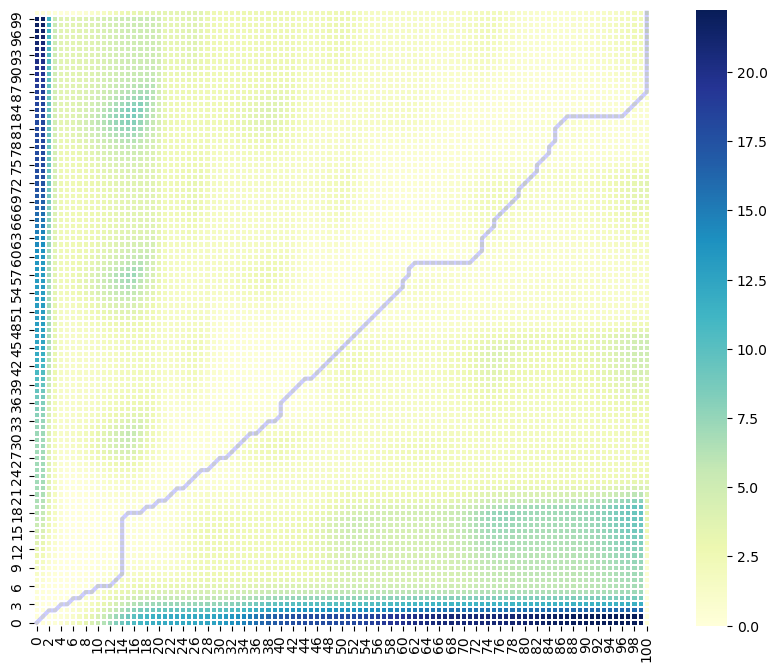

In [10]:
import seaborn as sbn
# Отрисуем матрицы весов расстояний Ts1 и Ts3 

cost_matrix = s1[2]
warp_path = s1[1]


fig, ax = plt.subplots(figsize=(12, 8))
ax = sbn.heatmap(cost_matrix, square=True, linewidths=0.1, cmap="YlGnBu", ax=ax)
ax.invert_yaxis()


path_x = [p[0] for p in warp_path]
path_y = [p[1] for p in warp_path]

# Align the path from the center of each cell
path_xx = [x+0.5 for x in path_x]
path_yy = [y+0.5 for y in path_y]

ax.plot(path_xx, path_yy, color='blue', linewidth=3, alpha=0.2)

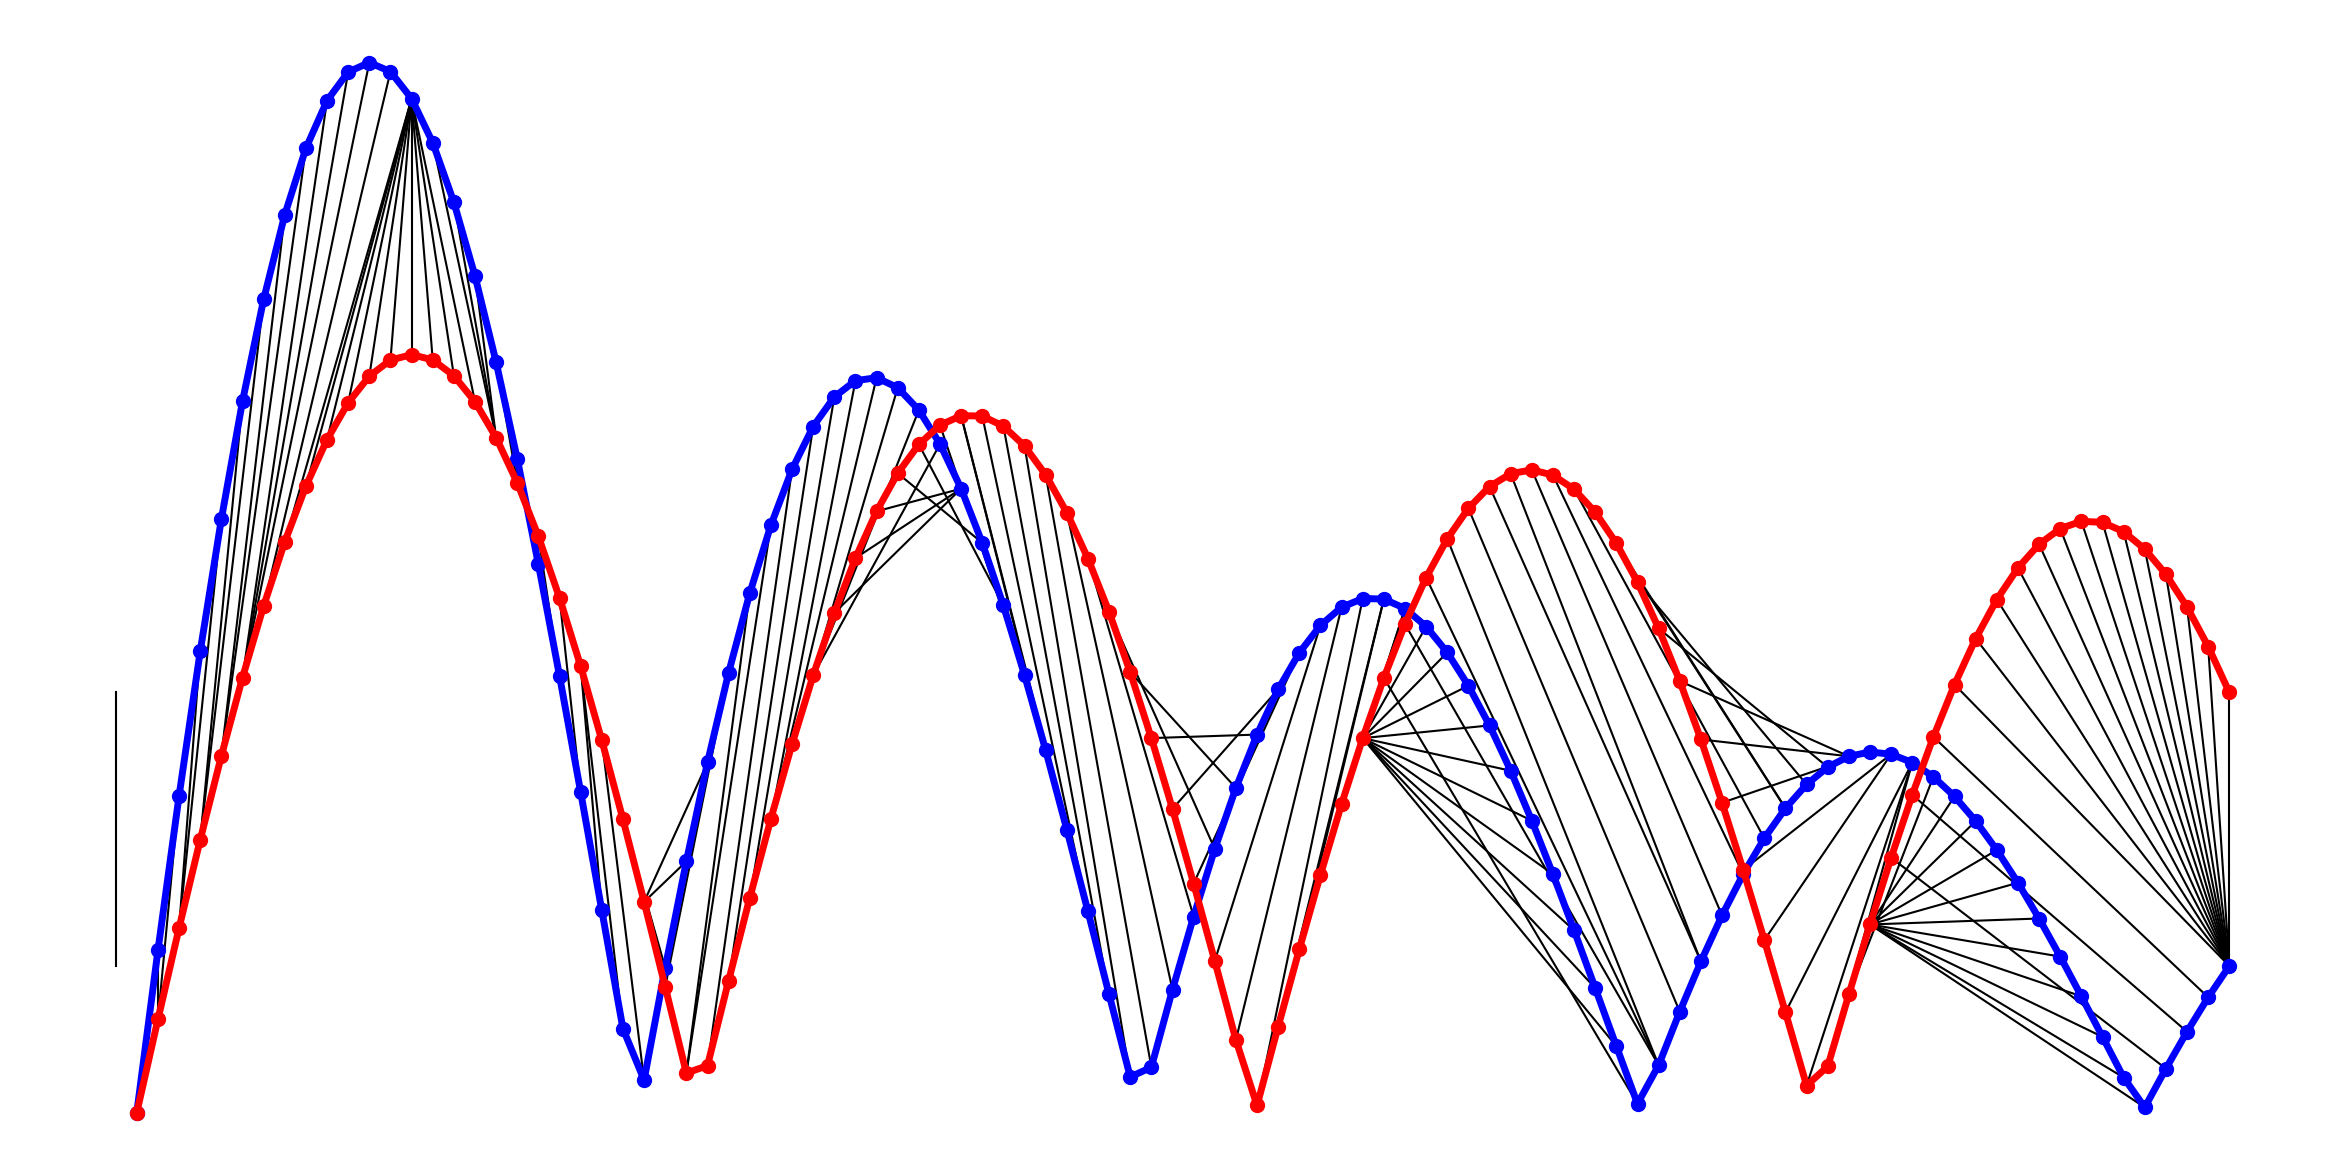

In [11]:
fig, ax = plt.subplots(figsize=(30, 15))


warp_path = s1[1]
x1 = x
x2 = x_s

# Remove the border and axes ticks
fig.patch.set_visible(True)
ax.axis('off')

for [map_x, map_y] in warp_path:   
    ax.set_facecolor('white')
    ax.plot([map_x-1, map_y-1], [x1[map_x-1], x2[map_y-1]], '-k')

ax.plot(x1, color='blue', marker='o', markersize=10, linewidth=5)
ax.plot(x2, color='red', marker='o', markersize=10, linewidth=5)
ax.tick_params(axis="both", which="major", labelsize=18)

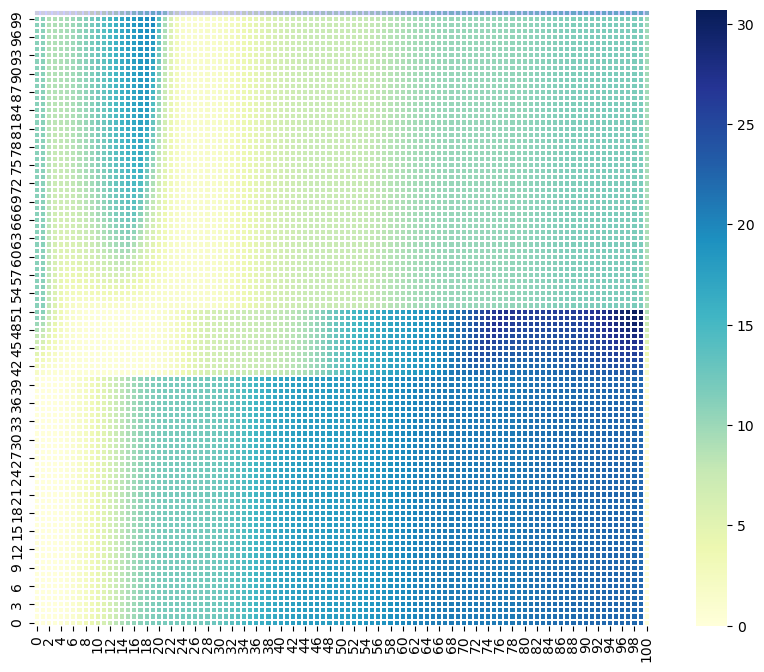

In [12]:
# Отрисуем матрицы весов расстояний Ts1 и Tp1

cost_matrix = s2[2]
warp_path = s2[1]

fig, ax = plt.subplots(figsize=(12, 8))
ax = sbn.heatmap(cost_matrix, square=True, linewidths=0.1, cmap="YlGnBu", ax=ax)
ax.invert_yaxis()


path_x = [p[0] for p in warp_path]
path_y = [p[1] for p in warp_path]

# Align the path from the center of each cell
path_xx = [x+0.5 for x in path_x]
path_yy = [y+0.5 for y in path_y]

ax.plot(path_xx, path_yy, color='blue', linewidth=3, alpha=0.2)

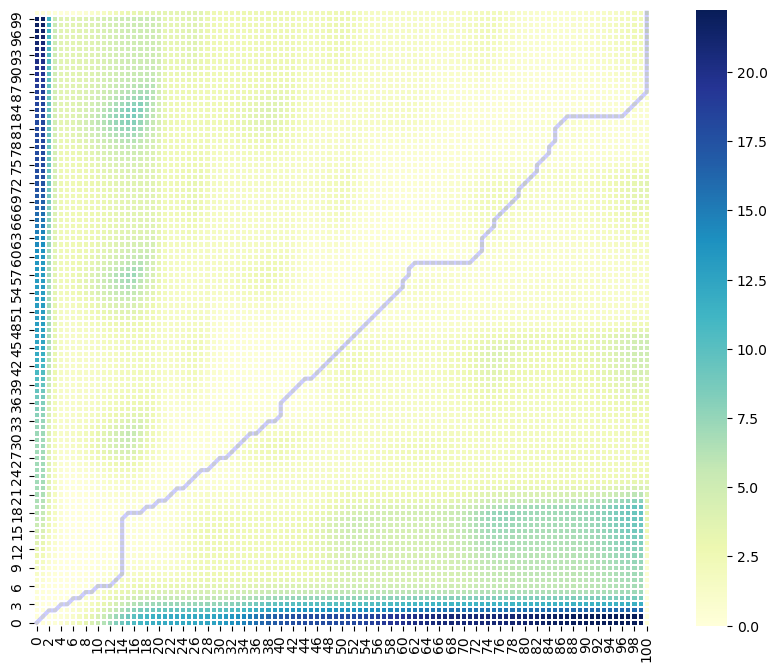

In [13]:
# Отрисуем матрицы весов расстояний Ts1 и Tp1 без DTW
import seaborn as sbn
cost_matrix = s1[2]
warp_path = s1[1]

fig, ax = plt.subplots(figsize=(12, 8))
ax = sbn.heatmap(cost_matrix, square=True, linewidths=0.1, cmap="YlGnBu", ax=ax)
ax.invert_yaxis()


path_x = [p[0] for p in warp_path]
path_y = [p[1] for p in warp_path]

# Align the path from the center of each cell
path_xx = [x+0.5 for x in path_x]
path_yy = [y+0.5 for y in path_y]

ax.plot(path_xx, path_yy, color='blue', linewidth=3, alpha=0.2)

А теперь попробуем вычислить тоже самое, но с помощью встроенных функций Python

In [14]:
from dtaidistance import dtw

x = np.abs(tseries_list.get("Ts1", np.zeros(100)))
x_s = np.abs(tseries_list.get("Ts6", np.zeros(100)))

# TODO: Вычислите расстояние и пути с помощью встроенной функции dtw.warping_paths из библиотеки dtaidistance
dist, paths = dtw.warping_paths(x, x_s)

print(dist)
print(paths)

1.446775536647183
[[0.                inf        inf ...        inf        inf        inf]
 [       inf 0.         0.08958997 ... 4.64661972 4.66814131 4.6855636 ]
 [       inf 0.155852   0.06626202 ... 3.32191566 3.33471446 3.34391127]
 ...
 [       inf 4.71415671 4.01089602 ... 1.56968909 1.49049696 1.39218051]
 [       inf 4.7154551  4.0109513  ... 1.61388069 1.52813905 1.42268661]
 [       inf 4.717556   4.01127789 ... 1.63870945 1.55866427 1.44677554]]


(<Figure size 1000x1000 with 4 Axes>, [<Axes: >, <Axes: >, <Axes: >, <Axes: >])

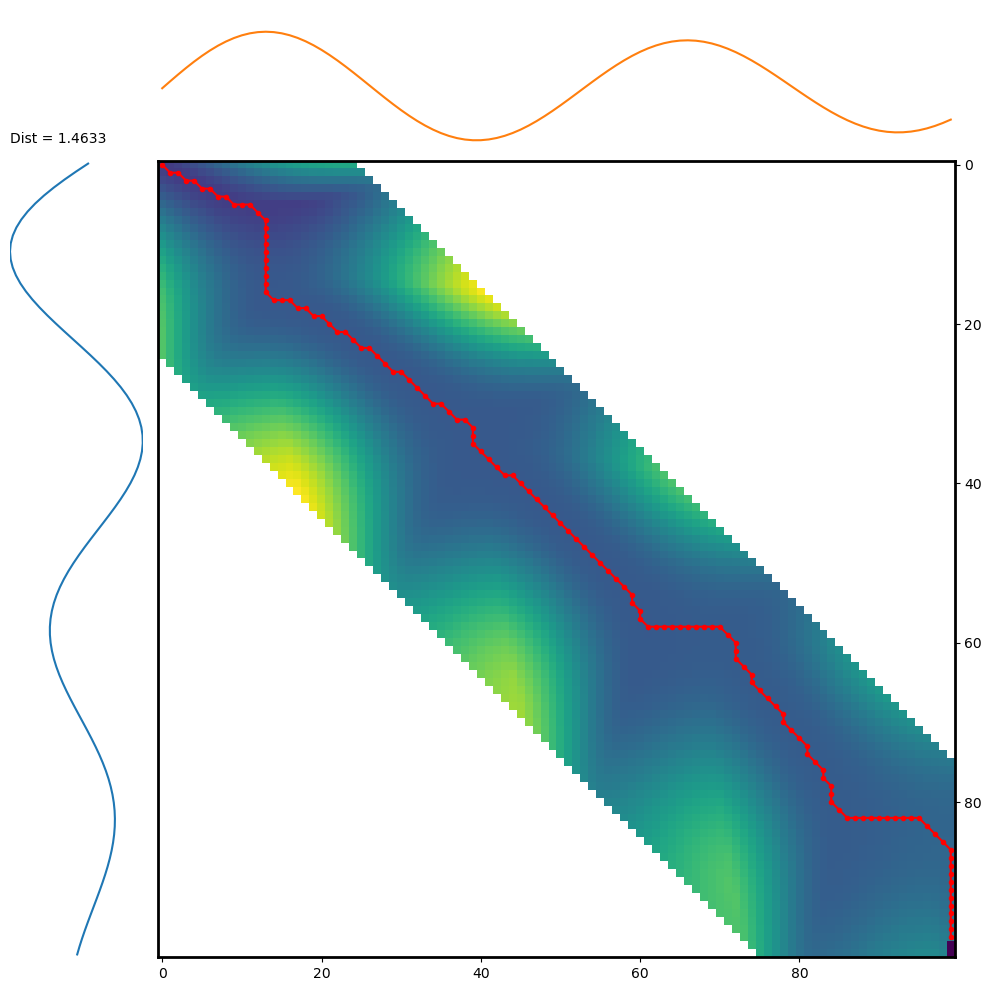

In [15]:
from dtaidistance import dtw
from dtaidistance import dtw_visualisation as dtwvis
import random
import numpy as np
s1 = np.array(tseries_list["Ts1"])
s2 = np.array(tseries_list["Ts6"])

distance, cost_matrix = dtw.warping_paths(s1, s2, window=25, psi=2)
cost_matrix = np.array(cost_matrix, dtype=float)
best_path = dtw.best_path(cost_matrix)
dtwvis.plot_warpingpaths(s1, s2, paths=cost_matrix, path=best_path)

In [16]:
x = np.abs(tseries_list["Ts1"])
x_p = np.abs(tseries_list["Tp2"])


distance, paths = dtw.warping_paths(x, x_p)
print(distance)
print(paths)

3.4241122251819047
[[0.                inf        inf ...        inf        inf        inf]
 [       inf 0.         0.         ... 3.31662479 3.31662479 3.31662479]
 [       inf 0.155852   0.155852   ... 2.99667601 3.00072607 3.00477067]
 ...
 [       inf 4.71415671 4.71415671 ... 3.41942735 3.41942735 3.41942735]
 [       inf 4.7154551  4.7154551  ... 3.42121715 3.42121715 3.42121715]
 [       inf 4.717556   4.717556   ... 3.42411223 3.42411223 3.42411223]]


(<Figure size 1000x1000 with 4 Axes>, [<Axes: >, <Axes: >, <Axes: >, <Axes: >])

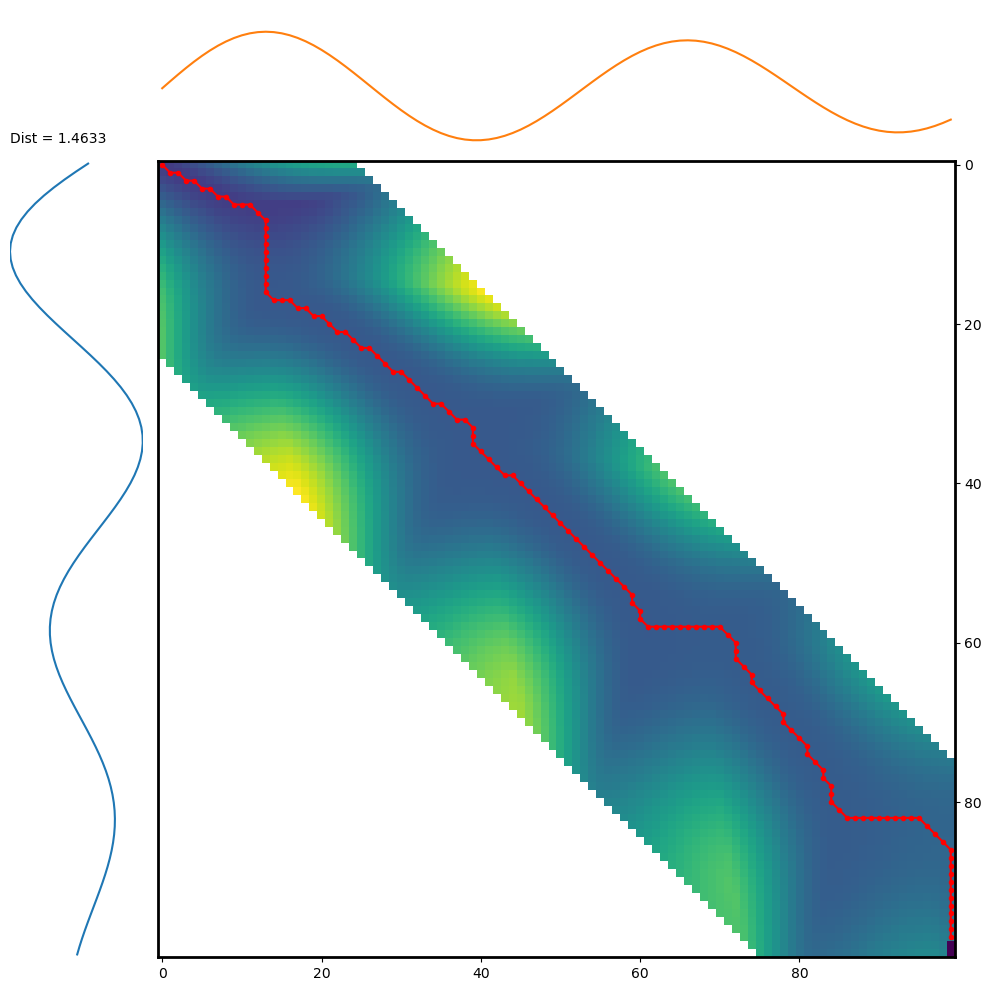

In [17]:
from dtaidistance import dtw
from dtaidistance import dtw_visualisation as dtwvis
import random
import numpy as np
s1 = np.array(tseries_list["Ts1"])
s2 = np.array(tseries_list["Ts6"])

distance, cost_matrix = dtw.warping_paths(s1, s2, window=25, psi=2)

cost_matrix = np.array(cost_matrix, dtype=float)

best_path = dtw.best_path(cost_matrix)

dtwvis.plot_warpingpaths(s1, s2, paths=cost_matrix, path=best_path)

In [18]:
# переделываем датасет так, чтобы с ним можно было бы работать

x = []  #значения
Y = []  # целевая переменная

for v in tseries_list:
    if v!= 'Time':
        x.append(tseries_list[v])
        c = v[:-1]
        if c == "Ts":
            Y.append(0)
        elif c == "Tc":
            Y.append(1)
        else: Y.append(2)


arr = np.arange(len(Y))
np.random.shuffle(arr)


print(Y)

X_train = []
X_test = []
y_train = []
y_test = []

# TODO: Заполните списки X_train, y_train, X_test, y_test
# Для этого отделите от перемешанных индексов arr последние 5 элементов под тест, 
# а остальные возьмите для трейна.
test_indices = arr[-5:]   # последние 5 элементов
train_indices = arr[:-5]  # все, кроме последних 5

X_train = [x[i] for i in train_indices]
y_train = [Y[i] for i in train_indices]
X_test = [x[i] for i in test_indices]
y_test = [Y[i] for i in test_indices]

[1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2]


In [19]:
from pyts.classification import KNeighborsClassifier

clf = KNeighborsClassifier(metric='dtw')
# TODO: Обучите модель методом clf.fit(...)

clf.fit(X_train, y_train)

print(f"Accuracy {clf.score(X_test, y_test)}")
print(f"Вектор вероятности принадлежности к классам {clf.predict_proba(X_test[2].reshape(1, -1))}")
print(f"Истинный класс для предсказаний {y_test[2]}")

Accuracy 1.0
Вектор вероятности принадлежности к классам [[1. 0. 0.]]
Истинный класс для предсказаний 0


In [22]:
import numpy as np 
from pyts.classification import TimeSeriesForest
import matplotlib.pyplot as plt

 
clf = TimeSeriesForest(random_state=43)
# TODO: Обучите модель методом clf.fit(...)

clf.fit(np.array(X_train), np.array(y_train))

print(f"Accuracy {clf.score(X_test, y_test)}")
print(f"Вектор вероятности принадлежности к классам {clf.predict_proba(X_test[2].reshape(1, -1))}")
print(f"Истинный класс для предсказаний {y_test[2]}")

Accuracy 0.8
Вектор вероятности принадлежности к классам [[0.476 0.492 0.032]]
Истинный класс для предсказаний 0


In [25]:
# TODO: Обучите модель KNN со стандартной (евклидовой) метрикой расстояния
# В домашнем задании требовалось сделать 3 модели на выбор.

from pyts.classification import KNeighborsClassifier

clf_eucl = KNeighborsClassifier(metric='euclidean')
# TODO: Обучите модель методом clf_eucl.fit(...)

clf_eucl.fit(np.array(X_train), np.array(y_train))
print(f"Accuracy {clf_eucl.score(X_test, y_test)}")
print(f"Вектор вероятности принадлежности к классам {clf_eucl.predict_proba(X_test[2].reshape(1, -1))}")
print(f"Истинный класс для предсказаний {y_test[2]}")

Accuracy 1.0
Вектор вероятности принадлежности к классам [[1. 0. 0.]]
Истинный класс для предсказаний 0
